# **Step 1 - Installation**

In [ ]:
# Install Java
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Download the latest Apache Spark version
!wget -q https://archive.apache.org/dist/spark/spark-3.4.1/spark-3.4.1-bin-hadoop3.tgz
!tar xf spark-3.4.1-bin-hadoop3.tgz

# Install findspark to connect Python with Spark
!pip install -q findspark


# **Step 2 - Environment Setup**

In [ ]:
# Import the os module to interact with the operating system
import os
# Import findspark to locate the Spark installation
import findspark

# Set the environment variable for Java home directory (required for Spark to run)
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
# Set the environment variable for Spark home directory to the downloaded Spark path
os.environ["SPARK_HOME"] = "/content/spark-3.4.1-bin-hadoop3"

# Initialize findspark to make pyspark importable within Python
findspark.init()


# **Step 3 - Create SparkSession**

In [ ]:
# Import SparkSession class from PySpark SQL module
from pyspark.sql import SparkSession

# Create a SparkSession object, which is the entry point to use Spark functionality
  # Set the name of the Spark application to be "Big Data Example"
  # Create a new SparkSession or return an existing one
spark = SparkSession.builder.appName("Big Data Example").getOrCreate()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Read measurements CSV

In [ ]:
import pandas as pd
import json

df = pd.read_csv(
    "/content/drive/MyDrive/نسخة من csv_json-20251229-2143.csv"
)

measurements = df["value"].apply(json.loads)

data = pd.DataFrame(
    measurements.tolist()
)

data.head()

,temperature,humidity,soil,tempThreshold,humThreshold
0,21.3,36.0,100,30.0,60.0
1,22.6,31.0,100,30.0,60.0
2,23.0,35.0,58,NaN,NaN
3,23.0,34.0,42,NaN,NaN
4,23.3,34.0,38,NaN,NaN


In [10]:
rdd = spark.sparkContext.parallelize(data.to_dict(orient='records'))
pairs = rdd.flatMap(lambda row: [(col, row[col]) for col in row.keys()])

print("MAP OUTPUT")

for item in rdd.take(15):
    print(item)

MAP OUTPUT
{'temperature': 21.3, 'humidity': 36.0, 'soil': 100, 'tempThreshold': 30.0, 'humThreshold': 60.0}
{'temperature': 22.6, 'humidity': 31.0, 'soil': 100, 'tempThreshold': 30.0, 'humThreshold': 60.0}
{'temperature': 23.0, 'humidity': 35.0, 'soil': 58, 'tempThreshold': nan, 'humThreshold': nan}
{'temperature': 23.0, 'humidity': 34.0, 'soil': 42, 'tempThreshold': nan, 'humThreshold': nan}
{'temperature': 23.3, 'humidity': 34.0, 'soil': 38, 'tempThreshold': nan, 'humThreshold': nan}
{'temperature': 23.2, 'humidity': 34.0, 'soil': 100, 'tempThreshold': nan, 'humThreshold': nan}
{'temperature': 23.3, 'humidity': 33.0, 'soil': 91, 'tempThreshold': nan, 'humThreshold': nan}
{'temperature': 23.3, 'humidity': 34.0, 'soil': 60, 'tempThreshold': nan, 'humThreshold': nan}
{'temperature': 23.4, 'humidity': 33.0, 'soil': 58, 'tempThreshold': nan, 'humThreshold': nan}
{'temperature': 23.4, 'humidity': 33.0, 'soil': 55, 'tempThreshold': nan, 'humThreshold': nan}
{'temperature': 23.3, 'humidity'

In [ ]:
min_values = rdd.reduceByKey(
    lambda a, b: a if a < b else b
)

print("MINIMUM VALUES:")
for parameter, value in min_values.collect():
    print(parameter, ":", value)

MINIMUM VALUES:
temperature : 17.4
humThreshold : nan
humidity : 27.0
soil : 8.0
tempThreshold : nan


In [ ]:
max_values = rdd.reduceByKey(
    lambda a, b: a if a > b else b
)

print("MAXIMUM VALUES:")
for parameter, value in max_values.collect():
    print(parameter, ":", value)

MAXIMUM VALUES:
temperature : 26.6
humThreshold : nan
humidity : 57.0
soil : 100.0
tempThreshold : nan


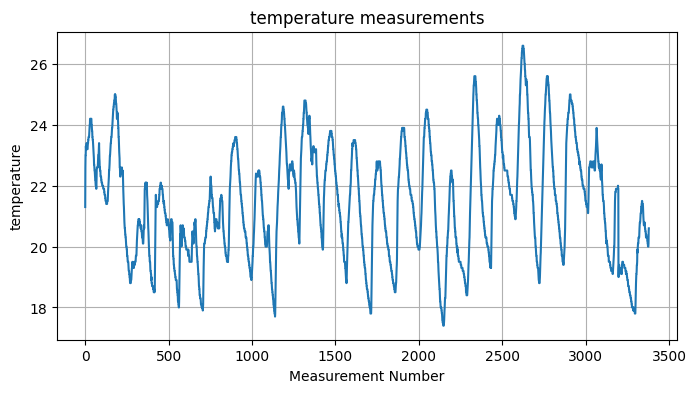

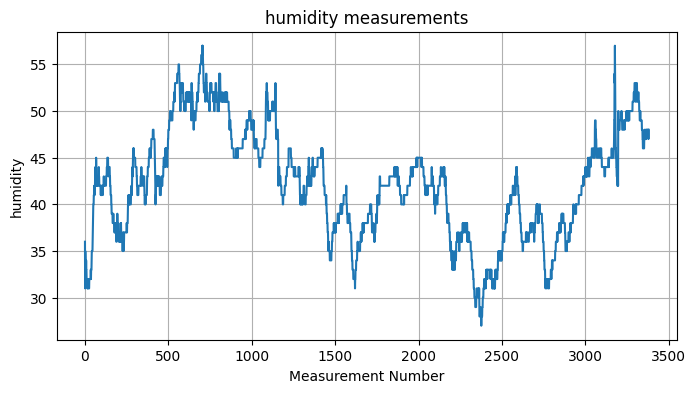

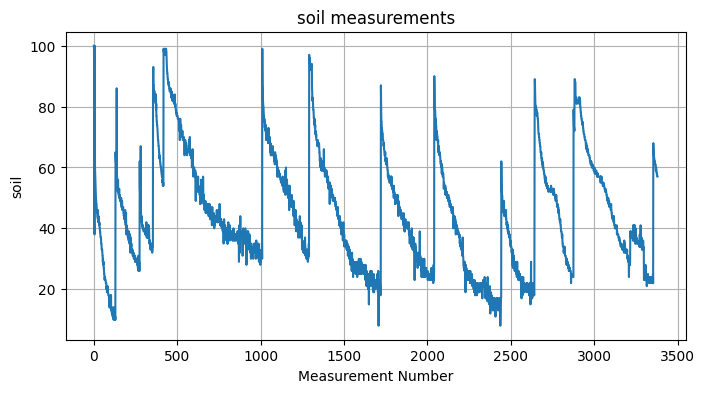

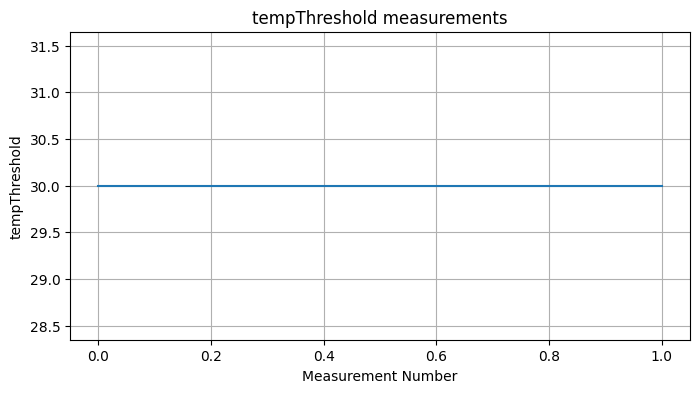

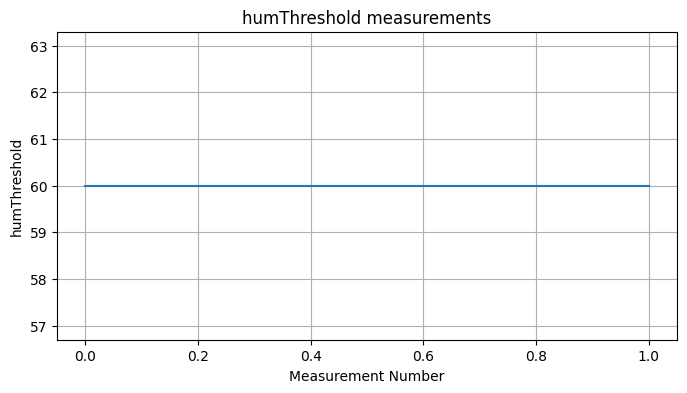

In [ ]:
import matplotlib.pyplot as plt

for column in data.columns:
    plt.figure(figsize=(8, 4))
    plt.plot(data[column])
    plt.title(f"{column} measurements")
    plt.xlabel("Measurement Number")
    plt.ylabel(column)
    plt.grid(True)
    plt.show()